# Example Notebook: Real Text Classification

This notebook gives a small, runnable example for supervised language tasks using a real labeled dataset rather than synthetic text.

The main ideas are:

- inspect the text and target labels;
- turn documents into TF-IDF features;
- compare a trivial reference baseline with a conventional text model;
- adapt the same scaffold later for interview excerpts, survey comments, or other labeled text data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

## 1. Load a small real text dataset

We use a two-class subset of `20 Newsgroups` as a stand-in for a labeled text problem. The labels here are topic labels, but the same starter workflow also works when your labels come from manual coding or any other existing annotation process.

In [2]:
categories = ['rec.autos', 'sci.med']
label_map = {'rec.autos': 'autos', 'sci.med': 'med'}

dataset = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
)

df = pd.DataFrame({
    'text': dataset.data,
    'label': [label_map[dataset.target_names[i]] for i in dataset.target],
})

df['word_count'] = df['text'].str.split().str.len()
df = df[df['word_count'] >= 20].copy()

# Keep a balanced subset so the notebook stays quick to run.
sampled_groups = []
for _, group in df.groupby('label'):
    sampled_groups.append(group.sample(n=min(len(group), 220), random_state=42))

df = pd.concat(sampled_groups, ignore_index=True)

display(df.head())
print('Rows:', len(df))

,text,label,word_count
0,My son is considering the purchase of a 71 MGB...,autos,275
1,\nLimited Tort Option will lower your rates. I...,autos,56
2,\nI think you mean ARPA; AARP is the American ...,autos,238
3,I'm about to buy a new car and finance some of...,autos,171
4,I'm having an interesting problem with my girl...,autos,214


Rows: 440


In [3]:
for label_name in ['autos', 'med']:
    example = df.loc[df['label'] == label_name, 'text'].sample(n=1).iloc[0]
    print(f'Random example from {label_name}:')
    print(example[:500])
    print()

Random example from autos:
Greetings automobile enthusiasts.  Can anyone tell me if there is
a mail order company that sells BMW parts discounted... cheaper than
the dealerships.

Sorry if it's a FAQ. email replies very much appreciated.

Thanks,

Random example from med:

Yeah, the "Feingold Diet" is a load of crap.  Children diagnosed with ADD
who are placed on this diet show no improvement in their intellectual and
social skills, which in fact continue to decline.  Of course, the parents
who are enthusiastic about this approach lap it up at the expense of their
children's development.  So much for the value of "interesting anecdotal
results".  People will believe anything if they want to.




In [4]:
label_summary = df.groupby('label')['word_count'].agg(['count', 'mean']).round(1)
display(label_summary)

,count,mean
label,,
autos,220,109.0
med,220,231.1


## 2. Inspect the target and a few examples

Before fitting a model, look at the label distribution and read a few examples. This helps you see whether the task is balanced and whether the wording seems related to the labels.

,text,label
265,You might look for an allergy doctor in your a...,med
78,<come along since the Mazda MPV. The NISSAN M...,autos
347,\nI saw a printed up flyer that stated the per...,med
255,\nProbably because most of them come packaged ...,med
327,someone wrote in expressing concern about gett...,med


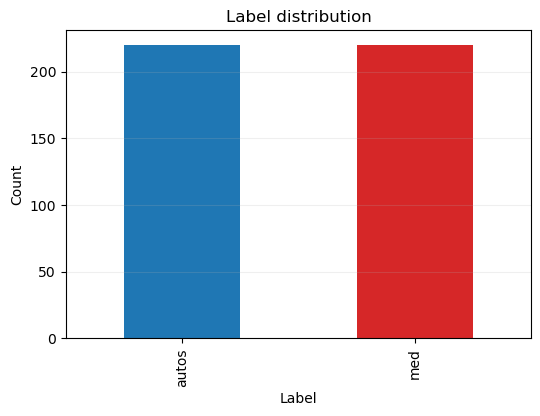

In [5]:
display(df[['text', 'label']].sample(5, random_state=42))

df['label'].value_counts().plot(kind='bar', color=['tab:blue', 'tab:red'], figsize=(6, 4))
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Label distribution')
plt.grid(True, axis='y', alpha=0.2)
plt.show()

## 3. Train-test split

We keep a test set separate so we can compare the reference baseline and the text model fairly.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))

Training rows: 352
Test rows: 88


## 4. Reference baseline

A trivial reference model for classification can always predict the most frequent class. It is weak, but it tells us whether the text model is learning anything useful from the documents.

In [7]:
reference_model = DummyClassifier(strategy='most_frequent')
reference_model.fit(np.arange(len(X_train)).reshape(-1, 1), y_train)
reference_predictions = reference_model.predict(np.arange(len(X_test)).reshape(-1, 1))

reference_accuracy = accuracy_score(y_test, reference_predictions)
print('Reference accuracy:', round(reference_accuracy, 3))

Reference accuracy: 0.5


## 5. First conventional baseline: TF-IDF plus logistic regression

This is a practical first model for a labeled text-classification task.
[TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) turns documents into numeric features by counting informative words or short phrases and down-weighting terms that appear everywhere.

In this starter version, we also remove common stop words such as "the", "is", and "of" before fitting the model. That helps the interpretation focus more on content words that are actually informative for the labels.

Logistic regression is a strong baseline for many TF-IDF text problems because it is fast, works well in high-dimensional sparse feature spaces, and gives coefficients that are easy to inspect later.

This baseline asks: if we represent the texts with TF-IDF after basic stop-word filtering, can a simple linear model separate the two classes reasonably well?

In [8]:
text_model = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, stop_words='english'),
    LogisticRegression(max_iter=1000, random_state=42)
)

text_model.fit(X_train, y_train)
text_predictions = text_model.predict(X_test)

text_accuracy = accuracy_score(y_test, text_predictions)

print('TF-IDF + logistic regression accuracy:', round(text_accuracy, 3))
print(classification_report(y_test, text_predictions, zero_division=0))

TF-IDF + logistic regression accuracy: 0.943
              precision    recall  f1-score   support

       autos       0.95      0.93      0.94        44
         med       0.93      0.95      0.94        44

    accuracy                           0.94        88
   macro avg       0.94      0.94      0.94        88
weighted avg       0.94      0.94      0.94        88



## 5b. Make a manual prediction for a new text

Once the model is fitted, you can give it a completely new text excerpt and ask for a predicted label.

This is useful when you want to test the model on an example you wrote yourself rather than only looking at the held-out test set.

For logistic regression, predicted probabilities are a simple first way to inspect how confident the model is.

In [9]:
example_text = "The mechanic explained the engine problem clearly, but the repair bill still felt far too high."

predicted_label = text_model.predict([example_text])[0]
predicted_probabilities = text_model.predict_proba([example_text])[0]

print('Example text:')
print(example_text)
print('\nPredicted label:', predicted_label)

for label, probability in zip(text_model.named_steps['logisticregression'].classes_, predicted_probabilities):
    print(f'Probability for {label}: {probability:.3f}')

Example text:
The mechanic explained the engine problem clearly, but the repair bill still felt far too high.

Predicted label: autos
Probability for autos: 0.558
Probability for med: 0.442


## 6. Inspect which words are associated with each label

One advantage of a linear text model is that we can inspect the fitted coefficients.

After TF-IDF converts words and short phrases into numeric features, logistic regression learns one coefficient per feature.
Because we remove common stop words first, the interpretation is less likely to be dominated by filler words such as "the" or "is" and more likely to highlight content words or short phrases.

- a positive coefficient pushes the model toward one class;
- a negative coefficient pushes the model toward the other class.

This is not the same as proving causation, and the coefficients depend on the whole dataset. But it gives a useful first look at model interpretation.

Terms pushing predictions toward 'autos':


,term,coefficient
840,car,-2.221651
875,cars,-1.217681
1814,engine,-1.065502
1408,dealer,-0.750247
4049,price,-0.711225
4243,rear,-0.702014
543,auto,-0.700582
1657,drive,-0.679735
4813,speed,-0.623041
792,buying,-0.619308


Terms pushing predictions toward 'med':


,term,coefficient
3467,msg,0.947604
1943,eye,0.798932
828,cancer,0.780275
3759,pain,0.740509
1585,doctor,0.723495
3279,medical,0.718455
685,blood,0.706717
2069,food,0.647335
1667,drug,0.614522
3293,medicine,0.610054


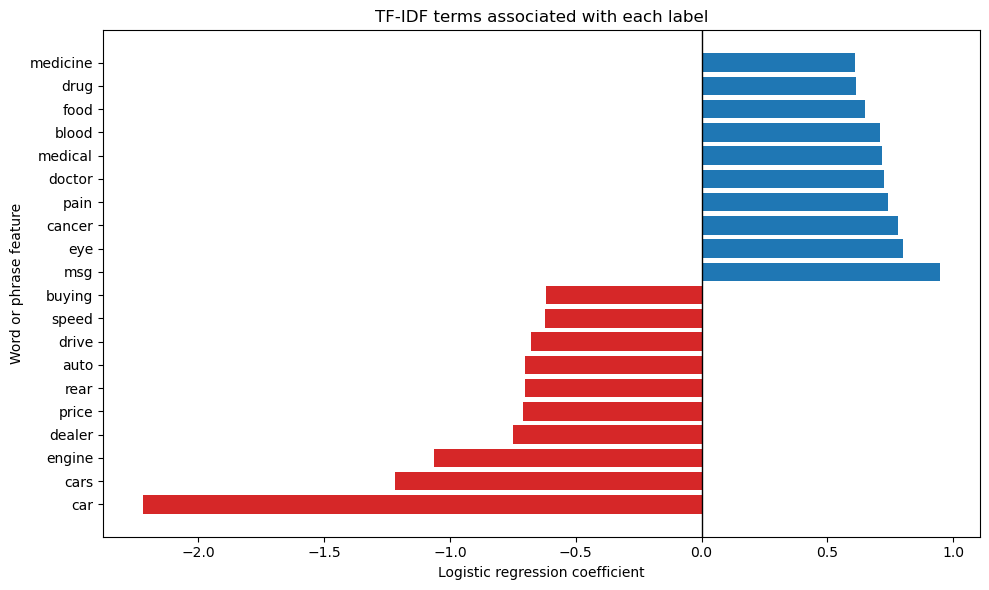

In [10]:
vectorizer = text_model.named_steps['tfidfvectorizer']
log_reg = text_model.named_steps['logisticregression']

feature_names = vectorizer.get_feature_names_out()
coefficients = np.asarray(log_reg.coef_).ravel()
negative_class, positive_class = log_reg.classes_[0], log_reg.classes_[1]

coef_df = pd.DataFrame(
    {
        'term': feature_names,
        'coefficient': coefficients,
    }
).sort_values('coefficient')

negative_terms = coef_df.head(10)
positive_terms = coef_df.tail(10).sort_values('coefficient', ascending=False)

print(f"Terms pushing predictions toward {negative_class!r}:")
display(negative_terms)

print(f"Terms pushing predictions toward {positive_class!r}:")
display(positive_terms)

plot_df = pd.concat([negative_terms, positive_terms], axis=0)
colors = ['tab:red' if value < 0 else 'tab:blue' for value in plot_df['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(plot_df['term'], plot_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Logistic regression coefficient')
plt.ylabel('Word or phrase feature')
plt.title('TF-IDF terms associated with each label')
plt.tight_layout()
plt.show()

## 7. Compare predictions with the true labels

A quick table and confusion matrix help you see where the model agrees with the true labels and where it makes mistakes.

For logistic regression, the highest predicted probability is a simple first notion of confidence.

,text,true_label,predicted_label,correct,max_probability
0,":Hello,\n:I heard that a certain disease (toxo...",med,med,True,0.549
1,\nYo! Watch the attributions--I didn't say tha...,autos,autos,True,0.512
2,"\n\tI was hoping for something like ""The chass...",autos,autos,True,0.738
3,eyes?\n\nBy looking at the iris (iridology) - ...,med,med,True,0.625
4,\nMy suggestion look at your current insurance...,autos,autos,True,0.580
...,...,...,...,...,...
83,[reply to roxannen@cruzio.santa-cruz.ca.u]\n \...,med,med,True,0.530
84,\nHow long ago was this? When I said you'd ge...,med,med,True,0.767
85,i of course car safety is important.. I for...,autos,autos,True,0.649
86,\n\n Nor is it mine. What I tried to explain...,med,med,True,0.742


Correct predictions: 83 out of 88


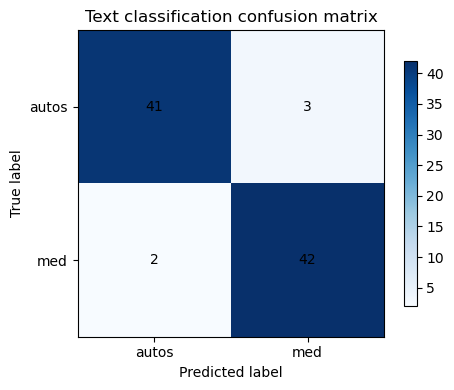

In [11]:
predicted_probabilities = text_model.predict_proba(X_test)
max_probability = predicted_probabilities.max(axis=1)

results_df = pd.DataFrame(
    {
        'text': X_test.values,
        'true_label': y_test.values,
        'predicted_label': text_predictions,
        'correct': y_test.values == text_predictions,
        'max_probability': np.round(max_probability, 3),
    }
).reset_index(drop=True)

display(results_df)

print('Correct predictions:', int(results_df['correct'].sum()), 'out of', len(results_df))

class_names = text_model.named_steps['logisticregression'].classes_
cm = confusion_matrix(y_test, text_predictions, labels=class_names)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Text classification confusion matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 8. What to change for your own text tasks

The same scaffold can be adapted for other language problems:

- sentiment or stance classification;
- theme classification;
- document type classification.

If you only want to explore patterns without labels, the workflow changes because there is no target variable. In that case it is better to use a separate exploratory workflow rather than forcing the problem into classification.

A practical next step after this notebook is to replace the example dataset with your own CSV file while keeping the same TF-IDF plus logistic regression workflow.

## 9. Optional extension: use your own CSV text dataset

If you already have your own text dataset in a CSV file, you can reuse the same supervised workflow.

This usually means one row per text example plus a label column.

Update:

- the file path;
- the text column name;
- the target column name.

Then keep the same train-test split, TF-IDF features, and logistic regression model.

In [12]:
# OPTIONAL EXTENSION
# Keep this flag set to False until you have updated the path and column names.

RUN_REAL_CSV_TEMPLATE = False

if RUN_REAL_CSV_TEMPLATE:
    text_path = 'data/your_text_dataset.csv'
    text_col = 'text'
    target_col = 'label'

    df_real = pd.read_csv(text_path)
    X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
        df_real[text_col],
        df_real[target_col],
        test_size=0.2,
        random_state=42,
        stratify=df_real[target_col],
    )

    model = make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, stop_words='english'),
        LogisticRegression(max_iter=1000, random_state=42),
    )
    model.fit(X_train_real, y_train_real)
    predictions = model.predict(X_test_real)

    print('Real CSV accuracy:', round(accuracy_score(y_test_real, predictions), 3))
    print(classification_report(y_test_real, predictions, zero_division=0))
else:
    print('Real CSV template is disabled. Set RUN_REAL_CSV_TEMPLATE = True after updating the path and column names.')

Real CSV template is disabled. Set RUN_REAL_CSV_TEMPLATE = True after updating the path and column names.


## 10. Takeaways

- Start with a real labeled text task or a labeled subset of your own data.
- TF-IDF is a strong first representation for many conventional language tasks.
- Always compare against a trivial reference baseline.
- A simple linear model such as logistic regression is a sensible first classifier for TF-IDF features.
- Inspect both predictive performance and the fitted coefficients.
- Once the workflow works on a real example, you can reuse the same structure on other labeled text datasets.
- If your text does not have labels yet, use a separate exploratory workflow rather than treating it as a classification problem too early.